# Task 3 
## Distributions and relationships (penguins.csv)
344 penguins from 3 species on 3 islands. Columns: species, island, bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g, sex.

This dataset has missing values — 2 penguins are missing all four measurements and 11 are missing sex. Find them first, decide what to do, and state your decision on the charts.

## Load and inspect the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("week 01 dataset\penguins.csv")

print("Shape:", df.shape)
display(df.head())

<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\M Saeed\AppData\Local\Temp\ipykernel_19428\2072825136.py:5: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv("week 01 dataset\penguins.csv")


Shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [2]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Find the penguins with missing measurements

In [3]:
measurement_cols = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

missing_measurements = df[df[measurement_cols].isnull().all(axis=1)]

print("Penguins missing all four measurements:")
display(missing_measurements)

Penguins missing all four measurements:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


There are 2 penguins missing all four measurements


## Now find the 11 penguins missing sex:

In [4]:
missing_sex = df[df["sex"].isnull()]

print("Penguins missing sex:", len(missing_sex))
display(missing_sex)

Penguins missing sex: 11


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


## Missing-value decision

The dataset contains 2 penguins with all four body measurements missing and 11 penguins with missing sex. I will exclude the 2 measurement-missing penguins from charts involving body mass or bill measurements because there is no valid measurement to plot. I will not remove the 11 penguins with missing sex from measurement-based analyses because their other measurements are still useful. However, they will be excluded from the species-and-sex comparison because their sex is unknown. I will not impute the missing values because the assignment does not require prediction, and replacing actual missing measurements with estimated values could introduce unnecessary assumptions.

## Create a clean dataset for measurement-based charts:

In [5]:
measurement_df = df.dropna(subset=measurement_cols).copy()

print("Original rows:", len(df))
print("Rows after removing missing measurements:", len(measurement_df))

Original rows: 344
Rows after removing missing measurements: 342


## 1. Distribution of body mass
One chart showing the distribution of body mass. What shape is it? Is it one hump or more?

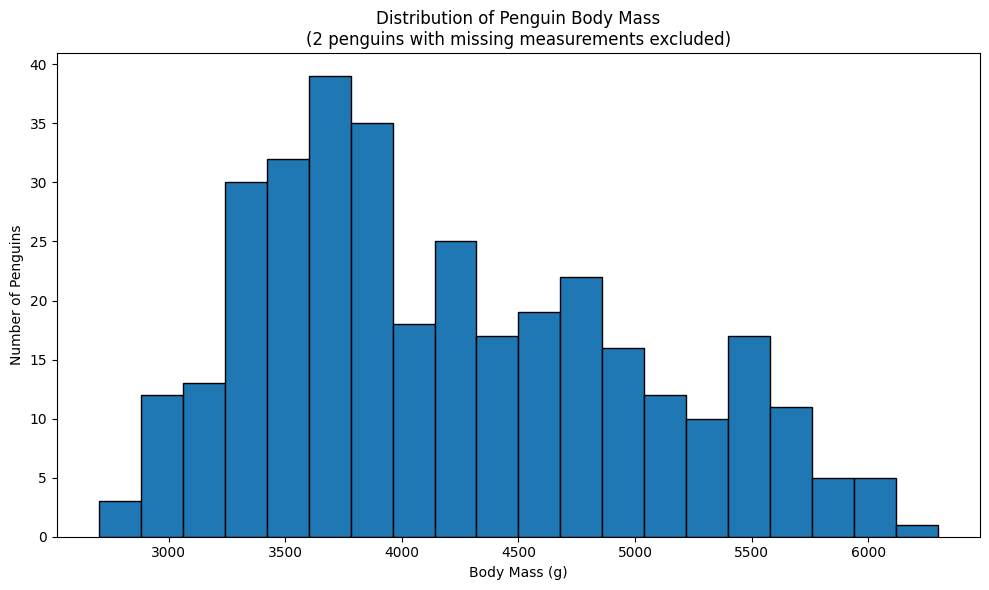

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    measurement_df["body_mass_g"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Penguin Body Mass\n(2 penguins with missing measurements excluded)")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")

plt.tight_layout()
plt.show()

## Interpretation

The body-mass distribution is not perfectly symmetrical.

You should see that it has more than one noticeable concentration/hump rather than behaving like one simple bell-shaped distribution.

This happens because the dataset contains three different penguin species, and those species have substantially different typical body masses.

So the first histogram mixes several populations together.

# 2. Redraw body mass split by species
Redraw it split by species. Does that explain the shape you saw in step 1?

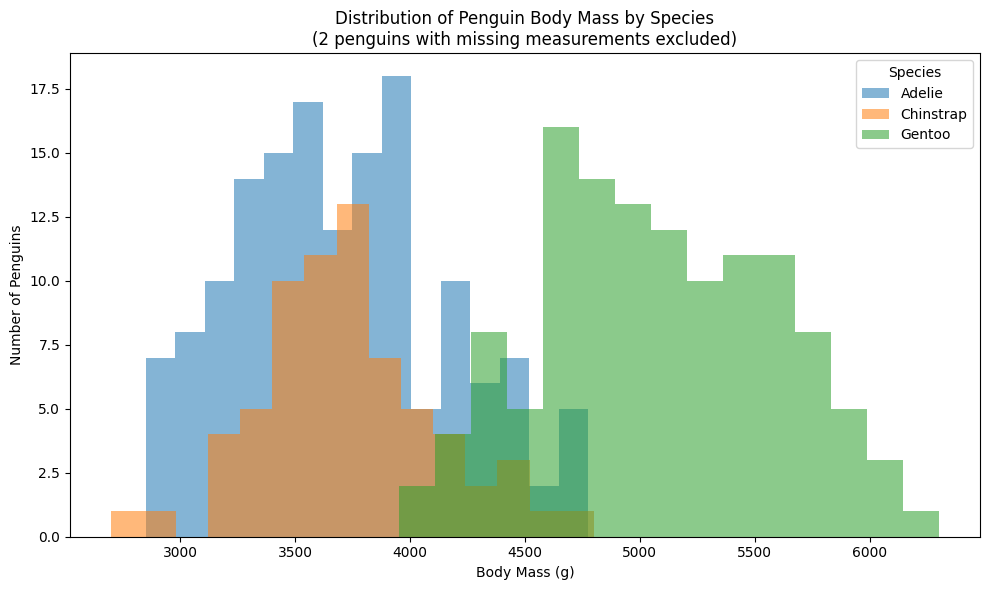

In [7]:
plt.figure(figsize=(10, 6))

for species, group in measurement_df.groupby("species"):
    plt.hist(
        group["body_mass_g"],
        bins=15,
        alpha=0.55,
        label=species
    )

plt.title("Distribution of Penguin Body Mass by Species\n(2 penguins with missing measurements excluded)")
plt.xlabel("Body Mass (g)")
plt.ylabel("Number of Penguins")
plt.legend(title="Species")

plt.tight_layout()
plt.show()

## Interpretation

Now the reason for the shape of the original distribution becomes clearer.

The three species have different body-mass distributions. When these distributions are combined into one histogram, their separate concentrations overlap and create a multi-hump distribution.

Therefore:

The multiple humps in the overall body-mass distribution are largely explained by the mixture of different penguin species.

This is a good example of why grouping data can reveal patterns that are hidden in an overall distribution.

# 3. Bill length vs bill depth
One scatter plot of bill length against bill depth, coloured by species. Something strange happens here: across all penguins the two measurements look negatively related, but within each species they are positively related. Draw it, then explain what is going on.

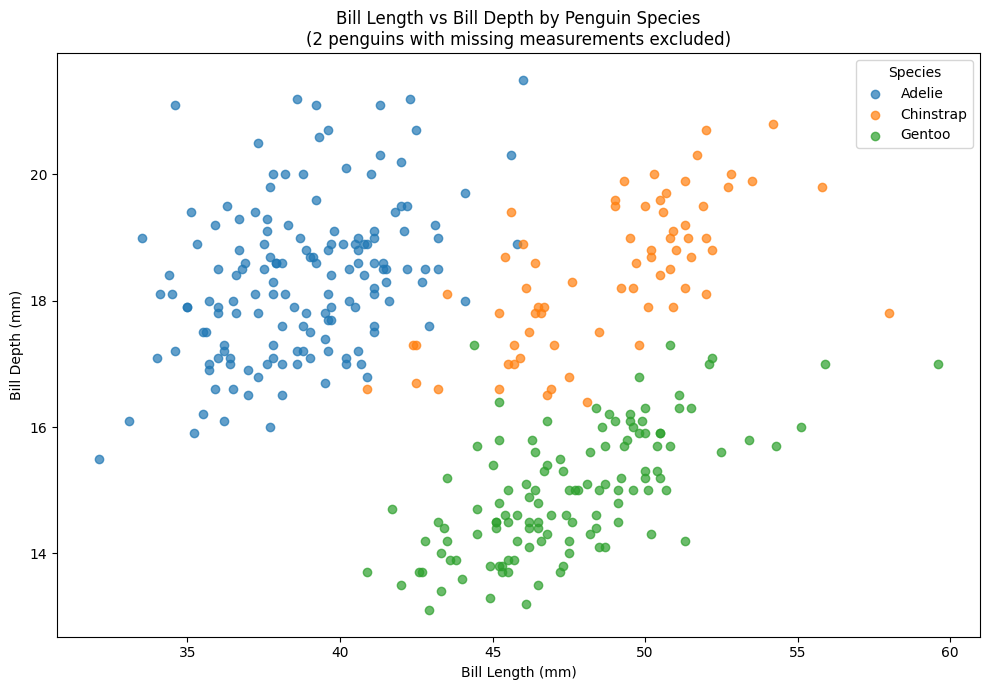

In [ ]:
plt.figure(figsize=(10, 7))

for species, group in measurement_df.groupby("species"):
    plt.scatter(
        group["bill_length_mm"],
        group["bill_depth_mm"],
        label=species,
        alpha=0.7
    )

plt.title("Bill Length vs Bill Depth by Penguin Species\n(2 penguins with missing measurements excluded)")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend(title="Species")

plt.tight_layout()
plt.show()

## Look at the overall relationship

First calculate the correlation using all penguins together:

In [9]:
overall_corr = measurement_df[
    ["bill_length_mm", "bill_depth_mm"]
].corr().iloc[0, 1]

print("Overall correlation:", round(overall_corr, 3))

Overall correlation: -0.235


In [10]:
species_corr = (
    measurement_df
    .groupby("species")[["bill_length_mm", "bill_depth_mm"]]
    .corr()
    .iloc[0::2, -1]
)

print(species_corr)

species                  
Adelie     bill_length_mm    0.391492
Chinstrap  bill_length_mm    0.653536
Gentoo     bill_length_mm    0.643384
Name: bill_depth_mm, dtype: float64


In [11]:
for species, group in measurement_df.groupby("species"):
    corr = group["bill_length_mm"].corr(group["bill_depth_mm"])
    print(f"{species}: {corr:.3f}")

Adelie: 0.391
Chinstrap: 0.654
Gentoo: 0.643


## So we have something apparently contradictory:

All penguins together       → negative relationship

Within each species         → positive relationship

The three species occupy different regions of the scatter plot.

For example, one species tends to have:

shorter bills
greater bill depth

while another tends to have:

longer bills
smaller bill depth

When we combine the species, these differences between species can create a negative overall trend.

But when we look inside each species separately, the relationship between bill length and bill depth is positive.

So the overall negative relationship is being driven largely by differences between the groups, rather than the relationship within each group.

# 4.One chart comparing average body mass across species and sex.
One chart comparing average body mass across species and sex.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("week 01 dataset\penguins.csv")

# Remove rows missing body mass or sex
plot_df = df.dropna(subset=["body_mass_g", "sex"])

# Calculate average body mass
avg_mass = (
    plot_df
    .groupby(["species", "sex"])["body_mass_g"]
    .mean()
    .reset_index()
)

display(avg_mass)

<>:4: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:4: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
C:\Users\M Saeed\AppData\Local\Temp\ipykernel_19428\694405551.py:4: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  df = pd.read_csv("week 01 dataset\penguins.csv")


,species,sex,body_mass_g
0,Adelie,FEMALE,3368.835616
1,Adelie,MALE,4043.493151
2,Chinstrap,FEMALE,3527.205882
3,Chinstrap,MALE,3938.970588
4,Gentoo,FEMALE,4679.741379
5,Gentoo,MALE,5484.836066


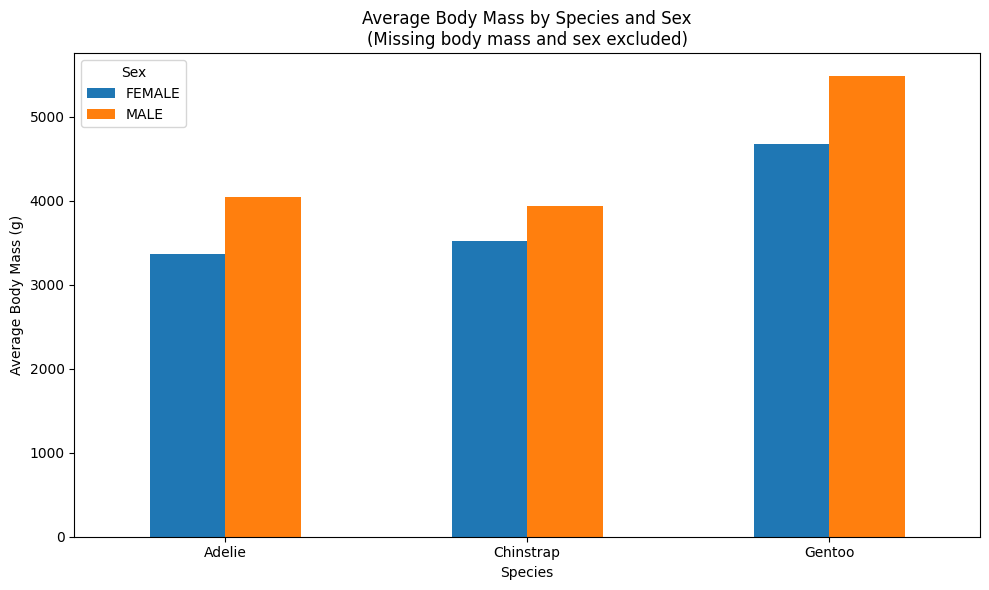

In [14]:
pivot = avg_mass.pivot(
    index="species",
    columns="sex",
    values="body_mass_g"
)

ax = pivot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title(
    "Average Body Mass by Species and Sex\n"
    "(Missing body mass and sex excluded)"
)
ax.set_xlabel("Species")
ax.set_ylabel("Average Body Mass (g)")

plt.xticks(rotation=0)
plt.legend(title="Sex")

plt.tight_layout()
plt.show()

The chart compares average body mass across the three penguin species and between sexes. Penguins with missing body mass or missing sex were excluded from this analysis. This allows body mass differences between species and between males and females to be examined separately.

# Simpson's paradox
Step 3 is the important one. The effect has a name — look up "Simpson's paradox" once you have drawn it — and it is the best possible argument for why you plot your groups separately.

**When all penguins are considered together, bill length and bill depth appear to have a negative relationship. However, when the data are separated by species, the relationship within each species is positive. This happens because the three species have different typical bill sizes, so differences between species dominate the overall relationship. The example demonstrates why it is important to examine groups separately rather than relying only on an
overall correlation.**

The species colouring isn't just making the graph prettier — it reveals that the overall relationship is misleading without considering species.